In [8]:
import numpy as np
import matplotlib.pyplot as plt

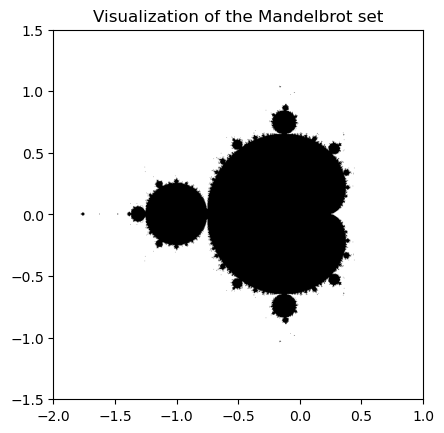

In [9]:
def iterations(c_grid: np.ndarray[np.complex128]) -> np.ndarray[bool]:
    max_it = 100
    N_max = 100
    z = np.zeros(c_grid.shape, dtype=np.complex128)
    flat_z = z.flatten()
    flat_c = c_grid.flatten()
    mask = np.full(flat_z.shape, True)

    for _ in range(max_it):
        flat_z[mask] = flat_z[mask]**2 + flat_c[mask]
        mask[abs(flat_z) > N_max] = False
    flat_z[mask] = 0
    flat_z[~mask] = 1
    fractal = flat_z.reshape(z.shape)

    return fractal
        

res = 800
x, y = np.mgrid[-2:1:res*1j, -1.5:1.5:res*1j] 
c = x + 1j*y
mask_c = iterations(c)
mask_c = abs(mask_c)
plt.imshow(mask_c.T, extent=[-2, 1, -1.5, 1.5])
plt.gray()
plt.title('Visualization of the Mandelbrot set')
plt.savefig('mandelbrot.png')
plt.show()